In [1]:
import pandas as pd

In [2]:
from sklearn.tree import DecisionTreeClassifier

In [3]:
datos = pd.read_csv("Datos/titanic.csv")

In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [9]:
datos.isnull().sum()[datos.isnull().sum() > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [10]:
datos.shape

(891, 12)

In [13]:
X = datos[["Pclass","Age","Sex"]].copy()

In [14]:
X.head()

,Pclass,Age,Sex
0,3,22.0,male
1,1,38.0,female
2,3,26.0,female
3,1,35.0,female
4,3,35.0,male


In [17]:
y = datos["Survived"]

In [18]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [19]:
print(type(X))

<class 'pandas.DataFrame'>


In [20]:
print(type(y))

<class 'pandas.Series'>


In [43]:
X["Sex"]= X["Sex"].map({
    "male":1,
    "female":0
})

In [44]:
promedio_edad = X["Age"].mean()

In [45]:
promedio_edad

np.float64(29.69911764705882)

In [27]:
X["Age"] = X ["Age"].fillna(promedio_edad)

In [28]:
X.isnull().sum()

Pclass    0
Age       0
Sex       0
dtype: int64

In [29]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     891 non-null    float64
 2   Sex     891 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 25.1 KB


In [32]:
ia = DecisionTreeClassifier()

In [35]:
type(ia)

sklearn.tree._classes.DecisionTreeClassifier

In [46]:
ia.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

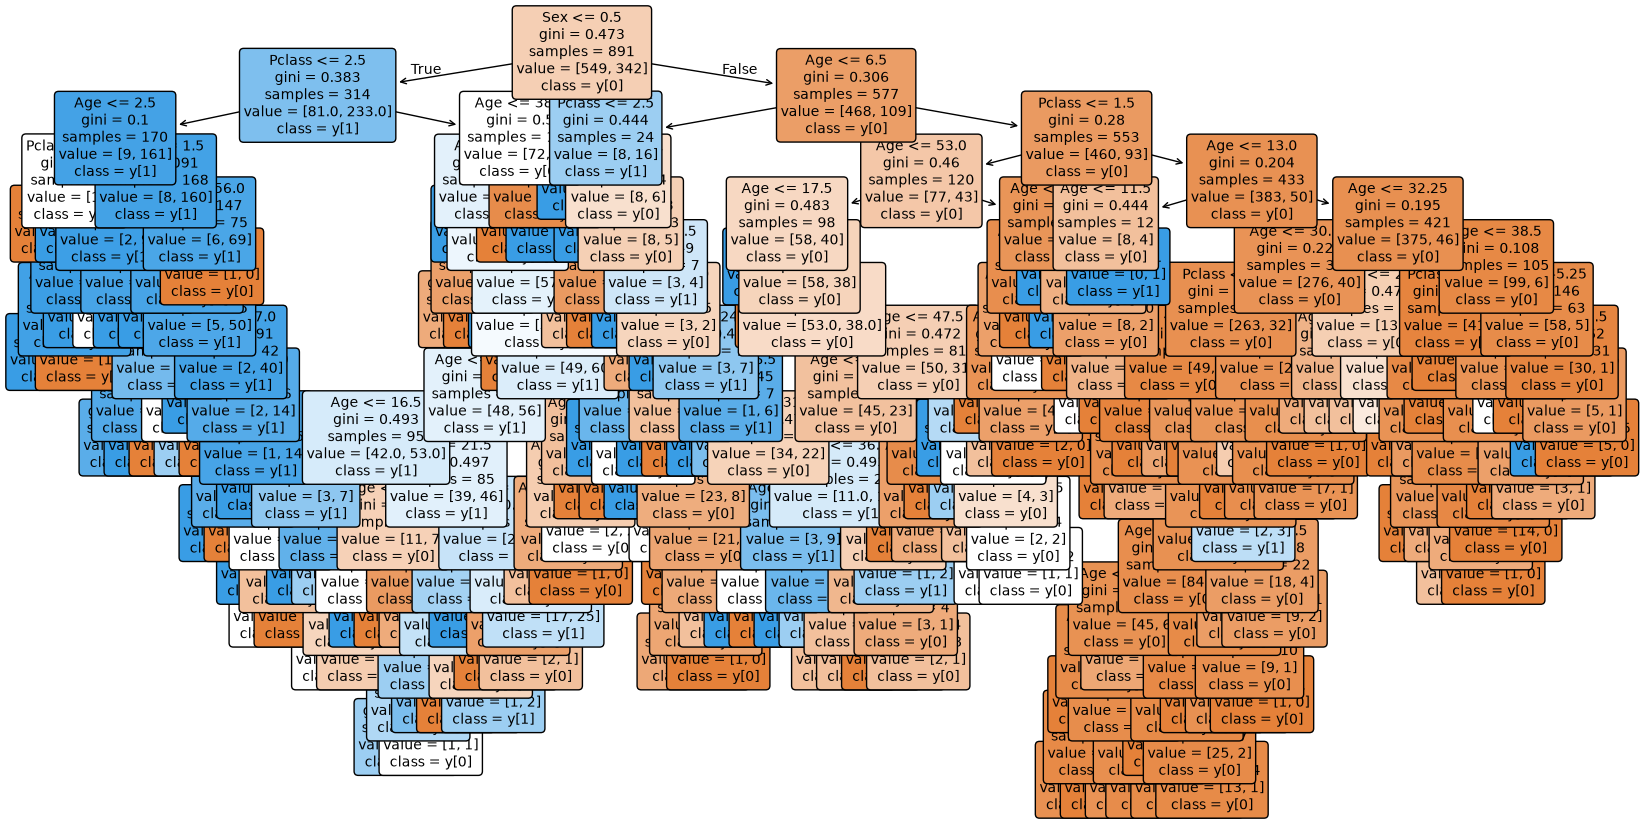

In [62]:
plt.figure(figsize=(20,10))

plot_tree(
    ia,
    filled=True,
    feature_names=X.columns,
    class_names=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [66]:
# 5. PEDIR DATOS AL USUARIO
# =========================================

print("\n=== NUEVO PASAJERO ===")

clase = int(input("Clase del pasajero (1,2,3): "))

sexo = input("Sexo (male/female): ")

edad = int(input("Edad: "))

# Convertir texto a número
if sexo == "female":
    sexo = 0
else:
    sexo = 1

# =========================================
# 6. HACER PREDICCIÓN
# =========================================

nuevo_pasajero = pd.DataFrame({
    "Pclass": [clase],
    "Age": [sexo],
    "Sex": [edad]
})

resultado = ia.predict(nuevo_pasajero)

# =========================================
# 7. RESULTADO
# =========================================

print("\n===================================")

if resultado[0] == 1:
    print("🎉 LA IA PREDICE QUE SOBREVIVIRÍA")
else:
    print("💀 LA IA PREDICE QUE NO SOBREVIVIRÍA")

print("===================================")



=== NUEVO PASAJERO ===


Clase del pasajero (1,2,3):  1
Sexo (male/female):  male
Edad:  5



🎉 LA IA PREDICE QUE SOBREVIVIRÍA
